In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb
import xgboost as xgb
from skopt import BayesSearchCV
from skopt.space import Real, Integer

In [2]:
data_prefix = "../0_data/processed_data/"
model_types = ['RF', 'XGB', 'LGB']
non_feature_cols = ['SMILES', 'MP', 'Ro5', 'Type']

In [3]:

def model_development(data, non_feature_cols, model_type):

    X = data.drop(columns=non_feature_cols)
    y = data['MP'].values
    strat_labels = data['Ro5'].values

    # Precompute folds stratified on Ro5 label (not continuous MP)
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    folds = list(skf.split(X, strat_labels))

    # ── Helper: run 10-fold CV for a given model instance ─────────────
    def run_cv(model_instance):
        fold_rmses = []
        for train_idx, val_idx in folds:
            X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_train, y_val = y[train_idx], y[val_idx]
            model_instance.fit(X_train, y_train)
            preds = model_instance.predict(X_val)
            fold_rmses.append(np.sqrt(mean_squared_error(y_val, preds)))
        return fold_rmses

    # ── Model + search space definitions ──────────────────────────────
    if model_type == 'RF':
        default_model = RandomForestRegressor(random_state=42, n_jobs=-1)
        base_model    = RandomForestRegressor(random_state=42, n_jobs=-1)
        search_space  = {
            'n_estimators':      Integer(50, 500),
            'max_depth':         Integer(3,    20),
            'min_samples_split': Integer(2,    20),
            'min_samples_leaf':  Integer(1,    10),
            'max_features':      Real(0.1, 1.0),
        }

    elif model_type == 'LGB':
        default_model = lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1)
        base_model    = lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1)
        search_space  = {
            'num_leaves':        Integer(20,   300),
            'max_depth':         Integer(3,    12),
            'learning_rate':     Real(0.01, 0.3,   prior='log-uniform'),
            'n_estimators':      Integer(50, 500),
            'min_child_samples': Integer(10,   50),
            'subsample':         Real(0.6, 1.0),
            'colsample_bytree':  Real(0.4, 1.0),
            'reg_alpha':         Real(1e-5, 10.0,  prior='log-uniform'),
            'reg_lambda':        Real(1e-5, 10.0,  prior='log-uniform'),
        }

    elif model_type == 'XGB':
        default_model = xgb.XGBRegressor(random_state=42, n_jobs=-1,
                                          tree_method='hist', verbosity=0)
        base_model    = xgb.XGBRegressor(random_state=42, n_jobs=-1,
                                          tree_method='hist', verbosity=0)
        search_space  = {
            'n_estimators':      Integer(50, 500),
            'max_depth':         Integer(3,    12),
            'learning_rate':     Real(0.01, 0.3,  prior='log-uniform'),
            'subsample':         Real(0.6, 1.0),
            'colsample_bytree':  Real(0.4, 1.0),
            'reg_alpha':         Real(1e-5, 10.0, prior='log-uniform'),
            'reg_lambda':        Real(1e-5, 10.0, prior='log-uniform'),
            'min_child_weight':  Integer(1,   10),
        }

    else:
        raise ValueError(f"model_type must be 'RF', 'LGB', or 'XGB'; got '{model_type}'")

    # ── Trial 0: default hyperparameters ──────────────────────────────
    trial_results = {}
    fold_rmses_0 = run_cv(default_model)
    mean_0 = float(np.mean(fold_rmses_0))
    std_0  = float(np.std(fold_rmses_0))
    trial_results[0] = {'fold_rmses': fold_rmses_0, 'mean_rmse': mean_0, 'std_rmse': std_0}
    print(f"Trial  0 (default) | mean RMSE: {mean_0:.4f} ± {std_0:.4f}")

    # ── Trials 1-20: BayesSearchCV ────────────────────────────────────
    # Pass precomputed folds as cv so BayesSearchCV never calls
    # StratifiedKFold.split(X, y) with a continuous y (which would error).
    opt = BayesSearchCV(
        base_model,
        search_space,
        n_iter=20,
        cv=folds,
        scoring='neg_root_mean_squared_error',
        random_state=42,
        n_jobs=1,
        refit=True,
    )
    opt.fit(X, y)

    # Extract per-trial fold RMSEs from cv_results_ (negate the neg-RMSE scores)
    n_splits = len(folds)
    for i in range(20):
        fold_rmses = [-opt.cv_results_[f'split{s}_test_score'][i] for s in range(n_splits)]
        mean_rmse  = float(np.mean(fold_rmses))
        std_rmse   = float(np.std(fold_rmses))
        trial_results[i + 1] = {
            'fold_rmses': fold_rmses,
            'mean_rmse':  mean_rmse,
            'std_rmse':   std_rmse,
        }
        print(f"Trial {i+1:>2d} | mean RMSE: {mean_rmse:.4f} ± {std_rmse:.4f}")

    # ── Best params & model (BayesSearchCV already refits on all data) ─
    best_model_info = {
        'best_params': opt.best_params_,
        'model':       opt.best_estimator_,
    }

    return trial_results, best_model_info


In [ ]:
for model in model_types:

    data = pd.read_parquet(data_prefix + f"data_with_selected_features_{model}_scaled.parquet")
    print(f"\n=== Model: {model} ===")
    # print the number of data and features
    print(f"Dataset shape: {data.shape} (n_samples={data.shape[0]}, n_features={data.shape[1] - len(non_feature_cols)})")
    trial_results, best_model_info = model_development(data, non_feature_cols, model_type=model)

    import pickle
    with open(f'model_development_results_{model}.pkl', 'wb') as f:
        pickle.dump(trial_results, f)
    with open(f'best_model_info_{model}.pkl', 'wb') as f:
        pickle.dump(best_model_info, f)



=== Model: RF ===
Dataset shape: (100, 67) (n_samples=100, n_features=63)


/Users/zeqing/opt/anaconda3/envs/LA/lib/python3.6/site-packages/sklearn/model_selection/_split.py:668: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=10.
  % (min_groups, self.n_splits)), UserWarning)


Trial  0 (default) | mean RMSE: 50.4600 ± 16.8726
Trial  1 | mean RMSE: 51.9844 ± 16.7048
Trial  2 | mean RMSE: 51.5111 ± 16.8791
Trial  3 | mean RMSE: 50.0834 ± 16.5475
Trial  4 | mean RMSE: 52.8968 ± 16.2658
Trial  5 | mean RMSE: 52.2263 ± 16.3824
Trial  6 | mean RMSE: 49.9687 ± 17.1236
Trial  7 | mean RMSE: 51.0709 ± 16.8772
Trial  8 | mean RMSE: 51.3685 ± 16.8994
Trial  9 | mean RMSE: 52.1470 ± 16.9379
Trial 10 | mean RMSE: 51.8675 ± 16.7349
Trial 11 | mean RMSE: 49.7474 ± 16.9440
Trial 12 | mean RMSE: 51.6938 ± 17.5577
Trial 13 | mean RMSE: 50.0630 ± 17.1147
Trial 14 | mean RMSE: 49.6096 ± 17.1388
Trial 15 | mean RMSE: 50.0865 ± 17.1137
Trial 16 | mean RMSE: 49.9065 ± 17.0539
Trial 17 | mean RMSE: 51.1100 ± 17.1543
Trial 18 | mean RMSE: 49.7021 ± 17.1470
Trial 19 | mean RMSE: 49.7893 ± 17.2714
Trial 20 | mean RMSE: 51.2142 ± 17.1105

=== Model: XGB ===
Dataset shape: (100, 57) (n_samples=100, n_features=53)


/Users/zeqing/opt/anaconda3/envs/LA/lib/python3.6/site-packages/sklearn/model_selection/_split.py:668: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=10.
  % (min_groups, self.n_splits)), UserWarning)


Trial  0 (default) | mean RMSE: 49.5177 ± 12.9767
Trial  1 | mean RMSE: 47.4801 ± 11.3292
Trial  2 | mean RMSE: 53.7802 ± 10.4099
Trial  3 | mean RMSE: 47.9019 ± 9.3452
Trial  4 | mean RMSE: 47.9800 ± 12.5284
Trial  5 | mean RMSE: 47.5522 ± 12.4942
Trial  6 | mean RMSE: 49.9601 ± 9.8158
Trial  7 | mean RMSE: 50.1403 ± 12.2174
Trial  8 | mean RMSE: 50.6577 ± 13.4850
Trial  9 | mean RMSE: 46.1478 ± 10.7581
Trial 10 | mean RMSE: 48.8019 ± 9.8154
Trial 11 | mean RMSE: 47.0853 ± 12.7372
Trial 12 | mean RMSE: 46.8944 ± 11.5453
Trial 13 | mean RMSE: 48.2687 ± 11.0241
Trial 14 | mean RMSE: 49.0490 ± 11.9868
Trial 15 | mean RMSE: 48.2624 ± 11.6512
Trial 16 | mean RMSE: 48.6063 ± 13.0389
Trial 17 | mean RMSE: 46.4543 ± 10.6566
Trial 18 | mean RMSE: 48.3711 ± 11.2525
Trial 19 | mean RMSE: 47.0399 ± 12.0837
Trial 20 | mean RMSE: 46.7309 ± 11.7160

=== Model: LGB ===
Dataset shape: (100, 112) (n_samples=100, n_features=108)


/Users/zeqing/opt/anaconda3/envs/LA/lib/python3.6/site-packages/sklearn/model_selection/_split.py:668: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=10.
  % (min_groups, self.n_splits)), UserWarning)


Trial  0 (default) | mean RMSE: 53.4952 ± 15.8132
Trial  1 | mean RMSE: 54.2105 ± 14.1171
Trial  2 | mean RMSE: 64.5213 ± 17.5430
Trial  3 | mean RMSE: 51.5080 ± 12.6398
Trial  4 | mean RMSE: 56.5645 ± 16.4127
Trial  5 | mean RMSE: 51.5881 ± 14.9302
Trial  6 | mean RMSE: 52.3714 ± 15.9417
Trial  7 | mean RMSE: 64.7145 ± 18.9666
Trial  8 | mean RMSE: 55.8539 ± 15.3416
Trial  9 | mean RMSE: 51.7020 ± 13.6610
Trial 10 | mean RMSE: 52.7413 ± 13.9035
Trial 11 | mean RMSE: 52.1502 ± 14.6933
Trial 12 | mean RMSE: 51.7703 ± 14.1144
Trial 13 | mean RMSE: 55.1015 ± 12.2012
Trial 14 | mean RMSE: 49.4216 ± 13.8971
Trial 15 | mean RMSE: 49.6327 ± 13.1096
Trial 16 | mean RMSE: 49.5514 ± 13.2350
Trial 17 | mean RMSE: 53.3037 ± 15.5481
Trial 18 | mean RMSE: 50.0135 ± 12.8897
Trial 19 | mean RMSE: 51.7049 ± 14.4013
Trial 20 | mean RMSE: 50.0414 ± 12.7537


In [6]:
import matplotlib.pyplot as plt

def plot_model_performance(model_development_results_dict):
    """
    Plot mean RMSE ± std as a function of HP tuning iteration.

    Parameters
    ----------
    model_development_results_dict : dict
        The trial_results dict returned by model_development().
        Keys = trial number (0 = default HP, 1-20 = BayesSearchCV iterations).
        Values = {'mean_rmse': float, 'std_rmse': float, ...}
    """
    trials     = sorted(model_development_results_dict.keys())
    mean_rmses = [model_development_results_dict[t]['mean_rmse'] for t in trials]
    std_rmses  = [model_development_results_dict[t]['std_rmse']  for t in trials]

    mean_rmses = np.array(mean_rmses)
    std_rmses  = np.array(std_rmses)

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(trials, mean_rmses, marker='o', linewidth=1.5, color='steelblue', label='Mean RMSE')
    ax.fill_between(trials,
                    mean_rmses - std_rmses,
                    mean_rmses + std_rmses,
                    alpha=0.25, color='steelblue', label='± 1 std')

    # Mark trial 0 (default HP) distinctly
    ax.axvline(x=0, color='grey', linestyle='--', linewidth=1, label='Default HP (trial 0)')

    # Highlight best trial
    best_trial = trials[int(np.argmin(mean_rmses))]
    best_rmse  = min(mean_rmses)
    ax.scatter([best_trial], [best_rmse], color='red', zorder=5,
               label=f'Best (trial {best_trial}, RMSE={best_rmse:.4f})')

    ax.set_xlabel('HP Tuning Iteration', fontsize=12)
    ax.set_ylabel('RMSE', fontsize=12)
    ax.set_title('Model Performance vs. HP Tuning Iteration', fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()



=== Performance plot for RF ===


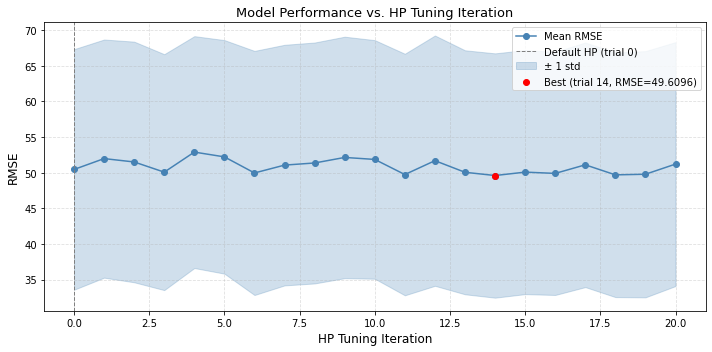


=== Performance plot for XGB ===


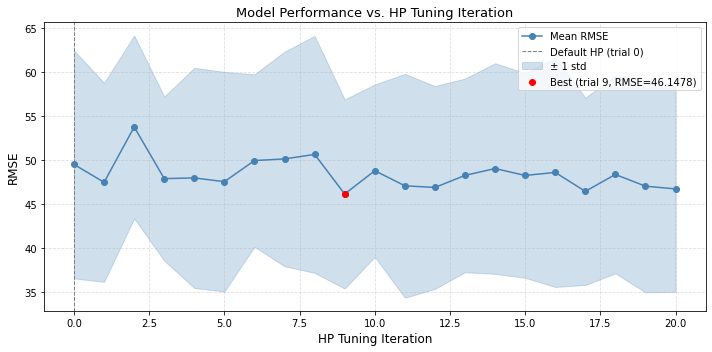


=== Performance plot for LGB ===


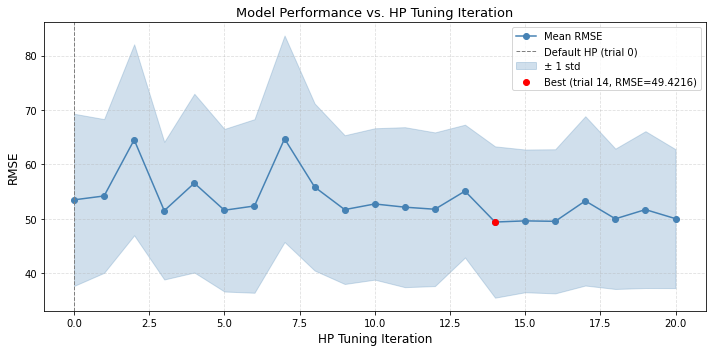

In [9]:
for model in model_types:
    print(f"\n=== Performance plot for {model} ===")

    with open(f'model_development_results_{model}.pkl', 'rb') as f:
        model_development_results = pickle.load(f)

    plot_model_performance(model_development_results)